In [1]:
# =====================================================================
# 1. CÀI ĐẶT TOÀN BỘ THƯ VIỆN LÊN ĐẦU (Chạy trên Kaggle)
# =====================================================================
!pip install -q "mcp>=1.0.0" ddgs markdownify smolagents openai

# Lưu ý về vLLM:
# - Nếu dùng API (Google AI Studio hoặc OpenRouter): KHÔNG CẦN cài vLLM (chạy CPU, không tốn GPU).
# - Chỉ cài vLLM nếu bạn muốn tự chạy model local trên GPU của Kaggle:
# !pip install -q "vllm>=0.8.5"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 1.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 3.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 38.5 MB/s eta 0:00:0000:0100:01


In [8]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [9]:
!git clone https://github.com/yandexdataschool/nlp_course.git


Cloning into 'nlp_course'...
remote: Enumerating objects: 4059, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 4059 (delta 190), reused 135 (delta 135), pack-reused 3819 (from 3)
Receiving objects: 100% (4059/4059), 602.64 MiB | 33.05 MiB/s, done.
Resolving deltas: 100% (2080/2080), done.
Updating files: 100% (407/407), done.


In [10]:
%cd /kaggle/working/nlp_course/week10_agents/seminar

/kaggle/working/nlp_course/week10_agents/seminar


In [11]:
import typing as tp
import subprocess

# PHẦN 1: THIẾT LẬP MÔ HÌNH NGÔN NGỮ (MODEL SETUP)

> **Ghi chú kiến thức:**
> - Khóa học hỗ trợ 3 cách kết nối LLM: **Google AI Studio** (Khuyên dùng - Miễn phí 1500 request/ngày, không cần GPU),
>   **OpenRouter** (Đa dạng model nhưng dễ dính rate limit nếu dùng free), và **vLLM** (Tự chạy local trên GPU Kaggle).
> - Bạn chỉ cần chọn một trong các provider bên dưới.


### Hướng dẫn lấy API Key:
- **Google AI Studio (Khuyên dùng):** Truy cập https://aistudio.google.com/apikey để lấy key hoàn toàn miễn phí.
- **OpenRouter:** Truy cập https://openrouter.ai/keys để tạo API key.


In [12]:
# =====================================================================
# 2. CHỌN PROVIDER CHO MÔ HÌNH
# =====================================================================
# Ưu tiên 'GoogleAIStudio': Miễn phí 1500 req/ngày, không cần nạp tiền, không lỗi 402/429
PROVIDER = 'GoogleAIStudio'

# Các lựa chọn khác:
# PROVIDER = 'OpenRouter'  # Dùng OpenRouter
# PROVIDER = 'vLLM'        # Tự host model local trên GPU Kaggle


In [14]:
from getpass import getpass

if PROVIDER == 'GoogleAIStudio':
    # =================================================================
    # CẤU HÌNH GOOGLE AI STUDIO (Khuyên dùng - Hoàn toàn MIỄN PHÍ)
    # Lấy key tại: https://aistudio.google.com/apikey
    # =================================================================
    MODEL = "gemini-3.5-flash-lite"  
    KEY = getpass("Your Google AI Studio API key: ")
    URL = "https://generativelanguage.googleapis.com/v1beta/openai/"

elif PROVIDER == 'OpenRouter':
    # =================================================================
    # CẤU HÌNH OPENROUTER
    # =================================================================
    # MODEL = "x-ai/grok-4.3" # Model trả phí (bắt buộc truyền max_tokens khi gọi)
    MODEL = "meta-llama/llama-3.3-70b-instruct:free" # Model miễn phí (có thể gặp 429 nếu nghẽn)
    KEY = getpass("Your OpenRouter API key: ")
    URL = "https://openrouter.ai/api/v1"

elif PROVIDER == 'vLLM':
    # =================================================================
    # CẤU HÌNH vLLM (Chạy local trên GPU Kaggle)
    # =================================================================
    KEY = "EMPTY"
    HOST = "127.0.0.1"
    PORT = "8999"
    MODEL = "Qwen/Qwen2.5-3B-Instruct"
    URL = f"http://{HOST}:{PORT}/v1"


Your Google AI Studio API key:  ········


In [ ]:
if PROVIDER == 'vLLM':
    vllm_server = subprocess.Popen([
        "python",
        "-m", "vllm.entrypoints.openai.api_server",
        "--model", MODEL,
        "--max_model_len", "16384",
        "--host", HOST,
        "--port", PORT,
        "--gpu_memory_utilization", "0.6",
        "--max_num_seqs", "16",
    ])
    #  python -m vllm.entrypoints.openai.api_server --model Qwen/Qwen3-4B-Instruct-2507 --max_model_len 16384 --host 127.0.0.1 --port 8999 --gpu_memory_utilization 0.6 --max_num_seqs 16 --temperature 0.9

# vllm_server.terminate() — остановить


In [15]:
from openai import OpenAI

client = OpenAI(
    base_url=URL,
    api_key=KEY,
)

# Gửi request kiểm tra kết nối
response = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Hi"}],
    # max_tokens=1000,  # Giới hạn max_tokens để tránh lỗi 402 nếu dùng OpenRouter
)

print("Response:", response.choices[0].message.content)


Response: Hello! How can I help you today?


# PHẦN 2: CÁCH VIẾT CÔNG CỤ (TOOLS) & GIAO THỨC MCP

**Agent (Tác tử)** khác mô hình LLM thông thường ở chỗ: Agent có khả năng **gọi công cụ bên ngoài (Tools)** để lấy thông tin thời gian thực từ Internet hoặc thực hiện các tác vụ tính toán mà LLM không làm chuẩn xác được.


## 2.1. Viết công cụ dưới dạng hàm Python thuần túy (Tools as Functions)

Ở bước này, ta xây dựng 2 công cụ cơ bản:
1. `duckduckgo_search(query)`: Tìm kiếm kết quả trên Internet thông qua DuckDuckGo.
2. `get_webpage_content(url)`: Tải mã HTML của trang web và chuyển thành định dạng Markdown gọn gàng.


In [16]:
from ddgs import DDGS

# =====================================================================
# CÔNG CỤ 1: TÌM KIẾM WEB BẰNG DUCKDUCKGO
# =====================================================================
def duckduckgo_search(query: str, max_results: int = 5):
    """
    Tìm kiếm trên DuckDuckGo và trả về danh sách các kết quả liên quan.
    Mỗi kết quả bao gồm: tiêu đề (title), đường dẫn (href), và tóm tắt ngắn (body).
    """
    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=max_results)
        return list(results)


In [17]:
duckduckgo_search('yandex data school')

[{'title': 'Yandex School of Data Analysis',
  'href': 'https://grokipedia.com/page/Yandex_School_of_Data_Analysis',
  'body': 'Yandex School of Data Analysis (also known as ShAD or Школа анализа данных Яндекса) is an independent educational institution founded by Yandex in 2007 in Moscow, Russia. It provides advanced postgraduate programs focused on…'},
 {'title': 'Yandex School of Data Analysis',
  'href': 'https://dataschool.yandex.com/',
  'body': 'Solving data collection and analysis tasks with modern tools — from Yandex Weather to large-scale systems such as Alice AI'},
 {'title': 'Yandex School of Data Analysis · GitHub',
  'href': 'https://github.com/yandexdataschool',
  'body': 'Yandex School of Data Analysis has 114 repositories available. Follow their code on GitHub.'},
 {'title': 'Academic programs at the Yandex School of Data Analysis',
  'href': 'https://dataschool.yandex.com/dataschool/education',
  'body': 'The Yandex School of Data Analysis provides a systematic educat

In [18]:
import re
import requests
from markdownify import markdownify
from requests.exceptions import RequestException

# =====================================================================
# CÔNG CỤ 2: TẢI VÀ CHUYỂN ĐỔI NỘI DUNG TRANG WEB SANG MARKDOWN
# =====================================================================
def get_webpage_content(url: str) -> str:
    """
    Truy cập vào một URL, tải mã HTML và dùng markdownify chuyển thành văn bản Markdown.
    Giúp loại bỏ thẻ HTML rườm rà, giảm số lượng token để đưa vào ngữ cảnh của LLM.
    """
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()  # Ném lỗi nếu mã HTTP >= 400

        # Chuyển đổi mã HTML thành Markdown
        markdown_content = markdownify(response.text).strip()
        # Thu gọn các dòng trống liên tiếp thành tối đa 2 dòng trống để tiết kiệm token
        markdown_content = re.sub(r"\n{3,}", "\n\n", markdown_content)

        return markdown_content

    except RequestException as e:
        return f"Lỗi khi kết nối đến trang web: {str(e)}"
    except Exception as e:
        return f"Đã xảy ra lỗi không xác định: {str(e)}"


In [19]:
# =====================================================================
# CÔNG CỤ TỔNG HỢP: TÌM KIẾM VÀ ĐỌC TOÀN VĂN TRANG WEB
# =====================================================================
def websearch_full_text(query, top_k=1) -> dict[str, tp.Any]:
    """
    Kết hợp cả 2 bước:
    1. Tìm top_k kết quả từ DuckDuckGo.
    2. Lần lượt truy cập từng link lấy toàn bộ nội dung chi tiết.
    """
    results = duckduckgo_search(query, max_results=top_k)
    full_text_results = {}
    for r in results:
        url = r.get('href')
        if url:
            content = get_webpage_content(url)
            full_text_results[url] = {
                'title': r.get('title', ''),
                'snippet': r.get('body', ''),
                'content': content
            }
    return full_text_results


In [20]:
# =====================================================================
# TEST HÀM: websearch_full_text
# =====================================================================
test_query = "Yandex School of Data Analysis"
print(f"Searching for: '{test_query}'...")
search_data = websearch_full_text(test_query, top_k=1)

for url, info in search_data.items():
    print("-" * 50)
    print("URL:", url)
    print("Title:", info.get('title'))
    print("Snippet:", info.get('snippet'))
    print("Content Preview (200 ký tự đầu):\n", info.get('content', '')[:200], "...")


Searching for: 'Yandex School of Data Analysis'...
--------------------------------------------------
URL: https://grokipedia.com/page/Yandex_School_of_Data_Analysis
Title: Yandex School of Data Analysis
Snippet: Yandex School of Data Analysis (also known as ShAD or Школа анализа данных Яндекса) is an independent educational institution founded by Yandex in 2007 in Moscow, Russia. It provides advanced postgraduate programs focused on…
Content Preview (200 ký tự đầu):
 Yandex School of Data Analysis â Grokipedia
     

[Search `âK`](/search)

Suggest Edit [Sign in](https://accounts.x.ai/check-login?redirect=grokipedia-com&return_to=%2Fpage%2FYandex_School_of_Dat ...


## 2.2. Model Context Protocol (MCP) Server

> **MCP là gì?**
> - Giao thức chuẩn mở do Anthropic phát triển, giúp các mô hình AI kết nối bảo mật với các công cụ bên ngoài.
> - File `ysda_tools.py` đóng vai trò là một **MCP Server** cung cấp các hàm tính toán số học, vector và ma trận.
> - Server này giao tiếp với Client qua dòng vào/ra chuẩn (**stdio transport**) bằng các gói tin JSON-RPC.


## 2.3. Khởi tạo MCP Client & Kết nối tới MCP Server

MCP Client sẽ chạy file `ysda_tools.py` như một tiến trình con (subprocess), sau đó yêu cầu server gửi danh sách các công cụ hiện có qua hàm `initialize()` và `list_tools()`.


In [21]:
import asyncio
from typing import Optional
from contextlib import AsyncExitStack

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

In [22]:
import sys
import asyncio
from typing import Optional
from contextlib import AsyncExitStack
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

# =====================================================================
# LỚP MCPClient: KẾT NỐI VÀ GỌI TOOLS QUA GIAO THỨC MODEL CONTEXT PROTOCOL
# =====================================================================
class MCPClient:
    def __init__(self, mcps: list[str]):
        self.session: Optional[ClientSession] = None
        # CẤU TRÚC MỚI: AsyncExitStack giúp quản lý nhiều async context managers cùng lúc
        # (thay vì phải lồng 'async with context1: async with context2:' rất sâu và khó đóng)
        self.exit_stack = AsyncExitStack()
        self.mcps = mcps
        self.tools = []

    async def connect_to_server(self, server_script_path: str):
        # Dùng sys.executable để lấy chính xác đường dẫn Python đang chạy trong Notebook Kernel
        command = sys.executable
        server_params = StdioServerParameters(
            command=command,
            args=[server_script_path],
            env=None
        )

        # 1. Khởi chạy tiến trình con chạy file server qua đường truyền stdio (stdin/stdout)
        stdio_transport = await self.exit_stack.enter_async_context(stdio_client(server_params))
        self.stdio, self.write = stdio_transport

        # 2. Thiết lập ClientSession trên đường truyền đó
        self.session = await self.exit_stack.enter_async_context(ClientSession(self.stdio, self.write))

        # 3. Gửi thông điệp initialize theo chuẩn JSON-RPC để bắt tay với Server
        await self.session.initialize()

        # 4. Yêu cầu server trả về danh sách toàn bộ các tools mà nó cung cấp
        response = await self.session.list_tools()
        self.tools = response.tools

    def list_tools(self):
        """In danh sách tên các tools đã kết nối thành công"""
        print("\nConnected to server with tools:", [tool.name for tool in self.tools])
        return self.tools

    async def call_tool(self, tool_name, args):
        """Gọi thực thi một tool trên server với tham số truyền vào"""
        result = await self.session.call_tool(tool_name, args)
        return result


In [23]:
import os

# Đảm bảo file ysda_tools.py tồn tại trong thư mục làm việc hiện tại
tools_file_path = './ysda_tools.py'
if not os.path.exists(tools_file_path):
    print(f"{tools_file_path} không tìm thấy, đang tự động tạo file...")
    with open(tools_file_path, 'w', encoding='utf-8') as f:
        f.write('''import numpy as np
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("Calculator")

@mcp.tool()
def add(a: float, b: float) -> float:
    return a + b

@mcp.tool()
def subtract(a: float, b: float) -> float:
    return a - b

@mcp.tool()
def multiply(a: float, b: float) -> float:
    return a * b

@mcp.tool()
def divide(a: float, b: float) -> float:
    if b == 0:
        raise ValueError("Division by zero")
    return a / b

def _to_vector(x):
    arr = np.array(x, dtype=float)
    if arr.ndim != 1:
        raise ValueError("Input must be a 1D list representing a vector.")
    return arr

def _to_matrix(x):
    arr = np.array(x, dtype=float)
    if arr.ndim != 2:
        raise ValueError("Input must be a 2D list representing a matrix.")
    return arr

@mcp.tool()
def vector_add(a: list, b: list) -> list:
    va, vb = _to_vector(a), _to_vector(b)
    if va.shape != vb.shape:
        raise ValueError("Vectors must have the same size.")
    return (va + vb).tolist()

@mcp.tool()
def vector_subtract(a: list, b: list) -> list:
    va, vb = _to_vector(a), _to_vector(b)
    if va.shape != vb.shape:
        raise ValueError("Vectors must have the same size.")
    return (va - vb).tolist()

@mcp.tool()
def vector_dot(a: list, b: list) -> float:
    va, vb = _to_vector(a), _to_vector(b)
    if va.shape != vb.shape:
        raise ValueError("Vectors must have the same size.")
    return float(np.dot(va, vb))

@mcp.tool()
def matrix_add(a: list, b: list) -> list:
    ma, mb = _to_matrix(a), _to_matrix(b)
    if ma.shape != mb.shape:
        raise ValueError("Matrices must have the same shape.")
    return (ma + mb).tolist()

@mcp.tool()
def matrix_multiply(a: list, b: list) -> list:
    ma, mb = _to_matrix(a), _to_matrix(b)
    try:
        result = ma @ mb
    except ValueError:
        raise ValueError(f"Incompatible matrix shapes: {ma.shape} x {mb.shape}")
    return result.tolist()

if __name__ == "__main__":
    mcp.run(transport="stdio")
''')
    print("Đã tự động tạo ysda_tools.py thành công!")

# Đổi tên từ 'client' -> 'mcp_client' để không ghi đè OpenAI client
mcp_client = MCPClient([])
await mcp_client.connect_to_server(tools_file_path)
tools = mcp_client.list_tools()




Connected to server with tools: ['add', 'subtract', 'multiply', 'divide', 'vector_add', 'vector_subtract', 'vector_dot', 'vector_elementwise_multiply', 'matrix_add', 'matrix_subtract', 'matrix_multiply', 'matrix_transpose']


In [24]:
# Kiểm tra tool đầu tiên được trả về từ MCP Server
if tools:
    print("First tool name:", tools[0].name)
    print("Description:", tools[0].description)
    print("Input Schema:", tools[0].inputSchema)


First tool name: add
Description: 
Input Schema: {'properties': {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}, 'required': ['a', 'b'], 'title': 'addArguments', 'type': 'object'}


# PHẦN 3: TỰ ĐỘNG CHUYỂN ĐỔI HÀM PYTHON THÀNH TOOL SCHEMA (OPENAI FORMAT)

> **Mục đích:** Để mô hình LLM (như GPT, Claude, Gemini) biết cách gọi hàm, ta phải cung cấp cho nó một bản mô tả cấu trúc JSON Schema (tên hàm, mô tả, danh sách tham số, kiểu dữ liệu).


In [25]:
# Ví dụ một bản mô tả Tool chuẩn JSON Schema theo format của OpenAI:
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_youtube_captions",
            "description": "Fetch YouTube captions for a given video ID",
            "parameters": {
                "type": "object",
                "properties": {
                    "video_id": {"type": "string"},
                    "lang": {"type": "string", "default": "en"}
                },
                "required": ["video_id"]
            }
        }
    }
]


In [26]:
import inspect
import typing

# =====================================================================
# CẤU TRÚC LẠ: PYTHON INTROSPECTION / REFLECTION
# Hàm này tự động 'soi' mã nguồn của một hàm Python bất kỳ để tự tạo ra
# cấu trúc JSON Schema theo chuẩn OpenAI Tool/Function calling
# =====================================================================

# Bảng ánh xạ từ kiểu dữ liệu Python sang kiểu dữ liệu của JSON Schema
PYTHON_TO_JSON = {
    str: "string",
    int: "integer",
    float: "number",
    bool: "boolean",
    list: "array",
    dict: "object",
}

def create_tool_description(func):
    # inspect.signature(func): Đọc chữ ký hàm (tên các tham số, kiểu dữ liệu, giá trị mặc định)
    sig = inspect.signature(func)
    # inspect.getdoc(func): Đọc chuỗi docstring để làm mô tả (description) cho LLM hiểu
    doc = inspect.getdoc(func) or ""
    params_schema = {"type": "object", "properties": {}, "required": []}

    for name, param in sig.parameters.items():
        annotation = param.annotation
        json_type = PYTHON_TO_JSON.get(annotation, "string")  # fallback về string nếu không nhận diện được
        entry = {"type": json_type}

        # Kiểm tra xem tham số có giá trị mặc định không, nếu không có thì bắt buộc (required)
        if param.default is not inspect.Parameter.empty:
            entry["default"] = param.default
        else:
            params_schema["required"].append(name)

        params_schema["properties"][name] = entry

    # Trả về format chuẩn OpenAI Function Calling
    return {
        "type": "function",
        "function": {
            "name": func.__name__,
            "description": doc,
            "parameters": params_schema,
        },
    }


In [27]:
# Convert python function to openai tool
tool_desc = create_tool_description(duckduckgo_search)
import json
print(json.dumps(tool_desc, indent=2))


{
  "type": "function",
  "function": {
    "name": "duckduckgo_search",
    "description": "T\u00ecm ki\u1ebfm tr\u00ean DuckDuckGo v\u00e0 tr\u1ea3 v\u1ec1 danh s\u00e1ch c\u00e1c k\u1ebft qu\u1ea3 li\u00ean quan.\nM\u1ed7i k\u1ebft qu\u1ea3 bao g\u1ed3m: ti\u00eau \u0111\u1ec1 (title), \u0111\u01b0\u1eddng d\u1eabn (href), v\u00e0 t\u00f3m t\u1eaft ng\u1eafn (body).",
    "parameters": {
      "type": "object",
      "properties": {
        "query": {
          "type": "string"
        },
        "max_results": {
          "type": "integer",
          "default": 5
        }
      },
      "required": [
        "query"
      ]
    }
  }
}


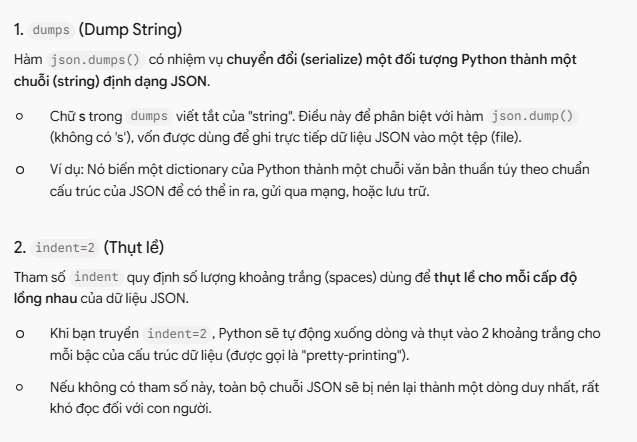

# PHẦN 4: XÂY DỰNG REACT AGENT THỦ CÔNG TỪ ĐẦU (FROM SCRATCH)

> **Mô hình ReAct (Reasoning + Acting):**
> - **Thought:** LLM suy luận, phân tích tình huống hiện tại (Ví dụ: 'Mình cần tìm thủ đô trước').
> - **Action:** LLM quyết định gọi một công cụ cụ thể: `Search[từ khóa]` hoặc `Visit web-page[url]` hoặc `Finish[kết quả]`.
> - **Observation:** Môi trường thực thi Action (gọi DuckDuckGo hoặc truy cập web) và trả kết quả thật về cho LLM.
> Vòng lặp tiếp diễn liên tục cho tới khi LLM có đủ thông tin và phát lệnh `Finish[câu trả lời]`.


In [28]:
instruction = """Solve a question answering task with interleaving Thought, Action, Observation steps. Thought can reason about the current situation, and Action can be three types:
(1) Search[query], which searches the web for the query and returns url, title and small snippet for 5 relevant pages.
(2) Visit web-page[link], which returns content of the page provided.
(3) Finish[answer], which returns the answer and finishes the task.
"""

final_prompt = """Solve a question answering task with interleaving Thought, Action, Observation steps. Thought can reason about the current situation, and Action can be three types:
(1) Search[query], which searches the web for the query and returns url, title and small snippet for 5 relevant pages.
(2) Visit web-page[link], which returns content of the page provided.
(3) Finish[answer], which returns the answer and finishes the task.

Here are some examples:

Question: What is the elevation range for the area that the Great Lakes Water Authority governs?
Thought 1: I need to search the Great Lakes Water Authority to find the area it governs, then find the elevation range of that area.
Action 1: Search[Great Lakes Water Authority area governed]
Observation 1: Title: Great Lakes Water Authority - Wikipedia
Link: https://en.wikipedia.org/wiki/Great_Lakes_Water_Authority
Snippet: The Great Lakes Water Authority provides water and wastewater services to 127 municipalities in Southeast Michigan...
Thought 2: The area governed is Southeast Michigan. I need to find the elevation range of Southeast Michigan.
Action 2: Search[Southeast Michigan elevation range]
Observation 2: Title: Geography of Michigan - Wikipedia
Link: https://en.wikipedia.org/wiki/Geography_of_Michigan
Snippet: Elevation ranges from the lake shores at 571 feet (174 m) to Mount Arvon at 1,979 feet (603 m)...
Thought 3: The elevation range is from 571 feet to 1,979 feet. I can now answer the question.
Action 3: Finish[571 feet to 1,979 feet]
Observation 3: Finish: 571 feet to 1,979 feet

Question: Which magazine was started first, Arthur's Home Magazine or Post?
Thought 1: I need to find the launch date of Arthur's Home Magazine and Post magazine.
Action 1: Search[Arthur's Home Magazine launch date]
Observation 1: Title: Arthur's Home Magazine - Wikipedia
Link: https://en.wikipedia.org/wiki/Arthur%27s_Home_Magazine
Snippet: Arthur's Home Magazine was an American magazine published from 1852 to 1898.
Thought 2: Arthur's Home Magazine was launched in 1852. Now I need to search for the launch date of Post magazine.
Action 2: Search[Post magazine launch date]
Observation 2: Title: The Saturday Evening Post - Wikipedia
Link: https://en.wikipedia.org/wiki/The_Saturday_Evening_Post
Snippet: The Saturday Evening Post was first published in 1821...
Thought 3: The Saturday Evening Post was started in 1821. Arthur's Home Magazine was started in 1852. So Post was started first.
Action 3: Finish[Post]
Observation 3: Finish: Post

Question: """


In [29]:
# =====================================================================
# HÀM GỌI LLM VỚI THAM SỐ DỪNG (STOP TOKENS)
# =====================================================================
def llm(prompt, stop=["\n"]):
    # stop tokens: Yêu cầu LLM ngừng sinh tiếp ngay khi gặp chuỗi này.
    # Rất quan trọng trong ReAct: LLM chỉ sinh đến Thought và Action, rồi DỪNG LẠI
    # để nhường quyền cho code Python chạy tool và trả về Observation!
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,      # temperature=0 để câu trả lời có tính tất định, suy luận logic chuẩn xác
        max_tokens=150,     # Giới hạn độ dài mỗi bước suy nghĩ
        stop=stop           # Dừng lại trước khi LLM tự 'bịa' ra kết quả Observation
    )
    return response.choices[0].message.content


In [30]:
# =====================================================================
# LUỒNG REACT AGENT (THỦ CÔNG TỪ ĐẦU - FROM SCRATCH)
# ReAct = Reason (Thought) + Act (Action) + Observation
# =====================================================================
def execute_action(action: str) -> str:
    """
    Thực thi hành động mà LLM vừa yêu cầu.
    Dùng Regular Expression (regex) để bóc tách: TênHànhĐộng[ThamSố]
    Ví dụ: 'Search[Hà Nội]' -> action_type = 'Search', arg = 'Hà Nội'
    """
    import re
    match = re.match(r"(\w+(?:\s+\w+)*)\[(.*)\]", action.strip())
    if not match:
        return f"Error: Sai định dạng hành động '{action}'. Cần định dạng Action[tham số]"

    action_type = match.group(1).strip()
    arg = match.group(2).strip()

    if action_type == "Search":
        try:
            results = duckduckgo_search(arg)
            formatted_results = []
            for r in results:
                formatted_results.append(
                    f"Title: {r.get('title', '')}\nLink: {r.get('href', '')}\nSnippet: {r.get('body', '')}\n"
                )
            return "\n".join(formatted_results)
        except Exception as e:
            return f"Lỗi khi tìm kiếm: {str(e)}"
    elif action_type == "Visit web-page":
        try:
            return get_webpage_content(arg)
        except Exception as e:
            return f"Lỗi khi truy cập trang web: {str(e)}"
    elif action_type == "Finish":
        return f"Finish: {arg}"
    else:
        return f"Lỗi: Không nhận diện được hành động '{action_type}'."


def call_react(question, prompt=final_prompt, to_print=True):
    """
    Vòng lặp ReAct lặp lại tối đa 7 bước:
    1. LLM sinh Thought (suy nghĩ) và Action (hành động cần làm)
    2. Code Python thực thi Action (gọi Search hoặc Visit webpage)
    3. Nạp kết quả Observation vào prompt và lặp tiếp cho tới khi gặp Finish[]
    """
    prompt += question + "\n"
    n_calls, n_badcalls = 0, 0
    answer = None

    for i in range(1, 8):
        n_calls += 1
        # Yêu cầu LLM sinh bước Thought thứ i
        prompt_with_guide = prompt + f"Thought {i}:"
        thought_action = llm(prompt_with_guide, stop=[f"\nObservation {i}:", f"Observation {i}:"])
        thought_action = f"Thought {i}:" + thought_action

        try:
            # Tách chuỗi để lấy riêng Thought và Action
            if f"\nAction {i}: " in thought_action:
                thought, action = thought_action.strip().split(f"\nAction {i}: ")
            elif "Action: " in thought_action:
                thought, action = thought_action.strip().split("Action: ")
            else:
                thought = thought_action.strip()
                action = "Finish[Không sinh được Action]"
        except Exception as e:
            thought = thought_action.strip()
            action = "Finish[Lỗi khi phân tích Action]"
            n_badcalls += 1

        # Thực thi hành động ngoài môi trường thực tế (gọi tool)
        obs = execute_action(action)

        if to_print:
            print(f"Thought {i}: {thought}")
            print(f"Action {i}: {action}")
            print(f"Observation {i}: {obs}\n")

        # Ghép Observation thực tế vào lịch sử prompt để LLM đọc ở vòng lặp tiếp theo
        obs_clean = obs.replace('\n', ' ')
        step_str = f"Thought {i}: {thought}\nAction {i}: {action}\nObservation {i}: {obs_clean}\n"
        prompt += step_str

        # Nếu Agent đã tìm ra câu trả lời cuối cùng -> Dừng vòng lặp
        if action.startswith("Finish"):
            import re
            ans_match = re.match(r"Finish\[(.*)\]", action)
            answer = ans_match.group(1) if ans_match else action
            break

    if answer is None:
        answer = "Không tìm thấy câu trả lời sau số bước tối đa"

    return answer, {"calls": n_calls, "badcalls": n_badcalls, "history": prompt}


In [31]:
# =====================================================================
# TEST HÀM: call_react (ReAct Agent thủ công)
# =====================================================================
test_question = "What is the capital of Vietnam and what is the name of its famous sword lake?"
print(f"Question: {test_question}\n")
answer, stats = call_react(test_question, to_print=True)

print("=" * 50)
print("FINAL ANSWER:", answer)
print(f"STATS: {stats['calls']} API calls, {stats['badcalls']} bad calls")


Question: What is the capital of Vietnam and what is the name of its famous sword lake?

Thought 1: Thought 1:I need to find the capital of Vietnam and the name of the famous sword lake located there.
Action 1: Search[capital of Vietnam famous sword lake]
Observation 1: Title: Sword Lake: The Everlasting Heartbeat of Vietnam's Capital
Link: https://asialegend.travel/blog/sword-lake-the-heartbeat-of-vietnam-capital
Snippet: Located in the heart of Vietnam's capital, Sword Lake (also known as Hoan Kiem Lake) is a popular tourist destination famous for visitors.

Title: Hoan Kiem Lake Hanoi | History + What to Do + Photo + Map
Link: https://vietnamdiscovery.com/hanoi/attractions/hoan-kiem-lake/
Snippet: History and Legend Hoan Kiem lake, also known as "Sword Lake," is a freshwater lake in the center of Hanoi. The legend about the name of the lake is known by all the Vietnamese people. Since they were small, they all learn about the story in their school about the most revered heroes, a gi

# PHẦN 5: HỆ THỐNG ĐA TÁC TỬ (MULTI-AGENT) VỚI THƯ VIỆN SMOLAGENTS

> **smolagents là gì?**
> Thư viện Agent tối giản và hiện đại của Hugging Face. Điểm đặc biệt của nó là:
> - Dùng **CodeAgent**: LLM không xuất chuỗi JSON mà tự viết code Python thực thi để giải bài toán.
> - Hỗ trợ phân cấp quản lý (**Hierarchical Multi-Agent**): Một `manager_agent` (quản lý) có thể điều phối `web_agent` (nhân viên chuyên tìm kiếm web).


In [32]:
from smolagents import tool

# =====================================================================
# SMOLAGENTS (Thư viện Agent mã nguồn mở hiện đại từ Hugging Face)
# Decorator @tool giúp chuyển hàm Python thành tool của smolagents.
# Lưu ý: Phải viết Docstring đúng chuẩn (Args, Returns) để thư viện tự parse schema.
# =====================================================================
@tool
def visit_webpage(link: str) -> str:
    """
    Visit web-page[link], which returns content of the page provided.
    Args:
        link: link to the webpage
    Returns:
        content of the webpage
    """
    return get_webpage_content(link)


In [33]:
from smolagents import (
    CodeAgent,
    OpenAIModel,
    ToolCallingAgent,
    WebSearchTool,
)

# Kết nối Model với smolagents qua endpoint OpenAI tương thích
model = OpenAIModel(
    model_id=MODEL,
    api_base=URL,
    api_key=KEY,
)

# CẤU TRÚC ĐẶC BIỆT CỦA SMOLAGENTS:
# CodeAgent: Thay vì sinh định dạng JSON truyền thống, Agent này sinh trực tiếp một đoạn mã Python
# rồi chạy ngầm trong sandbox để gọi tool và tính toán. Điều này giúp Agent xử lý logic và tính toán cực mạnh!
web_agent = CodeAgent(
    tools=[WebSearchTool(), visit_webpage],
    model=model,
    max_steps=5,
    name="web_search_agent",
    description="Runs web searches for you.",
)


In [34]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [35]:
# =====================================================================
# HỆ THỐNG ĐA TÁC TỬ (MULTI-AGENT SYSTEM) CỦA SMOLAGENTS:
# manager_agent là tác tử quản lý (sếp), nó không có tool tìm kiếm trực tiếp
# mà nó quản lý 'web_agent' (nhân viên) qua tham số managed_agents.
# Khi gặp câu hỏi cần tra cứu, manager_agent sẽ tự động giao việc cho web_agent!
# =====================================================================
manager_agent = CodeAgent(
    tools=[],
    model=model,
    managed_agents=[web_agent],
)


In [36]:
answer = manager_agent.run(
    "How does ReAct agent works? What metrics were reported by authors?"
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ How does ReAct agent works? What metrics were reported by authors?                                              │
│                                                                                                                 │
╰─ OpenAIModel - gemini-3.5-flash-lite ───────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = web_search_agent(                                                                                       
      task="Explain how the ReAct (Reasoning and Acting) agent works and detail the specific metrics reported by   
  the authors in the original paper (e.g., on HotpotQA, Fever, AlfWorld, WebShop).",                               
      additional_args={}                                                                                           
  )                                                                                                                
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

╭────────────────────────────────────────── New run - web_search_agent ───────────────────────────────────────────╮
│                                                                                                                 │
│ You're a helpful agent named 'web_search_agent'.                                                                │
│ You have been submitted this task by your manager.                                                              │
│ ---                                                                                                             │
│ Task:                                                                                                           │
│ Explain how the ReAct (Reasoning and Acting) agent works and detail the specific metrics reported by the        │
│ authors in the original paper (e.g., on HotpotQA, Fever, AlfWorld, WebShop).                                    │
│ ---                                                                                                             │
│ You're helping your manager solve a wider task: so make sure to not provide a one-line answer, but give as much │
│ information as possible to give them a clear understanding of the answer.                                       │
│                                                                                                                 │
│ Your final_answer WILL HAVE to contain these parts:                                                             │
│ ### 1. Task outcome (short version):                                                                            │
│ ### 2. Task outcome (extremely detailed version):                                                               │
│ ### 3. Additional context (if relevant):                                                                        │
│                                                                                                                 │
│ Put all these in your final_answer tool, everything that you do not pass as an argument to final_answer will be │
│ lost.                                                                                                           │
│ And even if your task resolution is not successful, please return as much context as possible, so that your     │
│ manager can act upon this feedback.                                                                             │
│                                                                                                                 │
╰─ OpenAIModel - gemini-3.5-flash-lite ───────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("""### How ReAct Agent Works:                                                                       
  The ReAct (Reasoning and Acting) framework synergizes verbal reasoning traces and task-specific actions in       
  large language models (LLMs) through an interleaved loop:                                                        
  $$\text{Thought}_t \rightarrow \text{Action}_t \rightarrow \text{Observation}_t \rightarrow                      
  \text{Thought}_{t+1} \rightarrow \dots$$                                                                         
                                                                                                                   
  - **Reasoning (Thoughts):** Allows the model to track, plan, and update action steps, decompose complex tasks,   
  and manage exceptions.                                                                                           
  - **Acting (Actions):** Allows the model to interact with external environments (such as search APIs, web        
  browsers, or simulators) to gather fresh information, reducing hallucinations and grounding responses.           
                                                                                                                   
  ### Metrics and Results Reported by the Authors:                                                                 
  1. **HotpotQA & Fever (Knowledge-Intensive Reasoning & Fact Verification):**                                     
     - **Metrics:** Exact Match (EM), F1 score, and Fact Verification Accuracy.                                    
     - **Results:** ReAct outperforms Act-only baselines and provides grounded, verifiable answers. Combining      
  ReAct with Self-Consistency (`ReAct + CoT-SC`) achieved the strongest prompting performance. Fine-tuning models  
  on ReAct trajectories outperformed CoT fine-tuning due to external grounding.                                    
                                                                                                                   
  2. **ALFWorld (Text-based Embodied Decision Making):**                                                           
     - **Metrics:** Success Rate (%).                                                                              
     - **Results:** ReAct outperformed baseline imitation learning and reinforcement learning methods by an        
  absolute success rate of **34%** using only 1–2 in-context examples.                                             
                                                                                                                   
  3. **WebShop (Webpage Navigation & Shopping):**                                                                  
     - **Metrics:** Success Rate (%) and Average Reward.                                                           
     - **Results:** ReAct improved success rate by an absolute **10%** over baselines by effectively searching,    
  clicking, and satisfying user constraints in a web environment.""")                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

<unknown>:3: SyntaxWarning: invalid escape sequence '\d'


Final answer: ### How ReAct Agent Works:
The ReAct (Reasoning and Acting) framework synergizes verbal reasoning traces and task-specific actions in large 
language models (LLMs) through an interleaved loop:
$$      ext{Thought}_t ightarrow        ext{Action}_t ightarrow         ext{Observation}_t ightarrow    
ext{Thought}_{t+1} ightarrow \dots$$

- **Reasoning (Thoughts):** Allows the model to track, plan, and update action steps, decompose complex tasks, and 
manage exceptions.
- **Acting (Actions):** Allows the model to interact with external environments (such as search APIs, web browsers,
or simulators) to gather fresh information, reducing hallucinations and grounding responses.

### Metrics and Results Reported by the Authors:
1. **HotpotQA & Fever (Knowledge-Intensive Reasoning & Fact Verification):**
   - **Metrics:** Exact Match (EM), F1 score, and Fact Verification Accuracy.
   - **Results:** ReAct outperforms Act-only baselines and provides grounded, verifiable answers. Combining ReAct 
with Self-Consistency (`ReAct + CoT-SC`) achieved the strongest prompting performance. Fine-tuning models on ReAct 
trajectories outperformed CoT fine-tuning due to external grounding.

2. **ALFWorld (Text-based Embodied Decision Making):**
   - **Metrics:** Success Rate (%).
   - **Results:** ReAct outperformed baseline imitation learning and reinforcement learning methods by an absolute 
success rate of **34%** using only 1–2 in-context examples.

3. **WebShop (Webpage Navigation & Shopping):**
   - **Metrics:** Success Rate (%) and Average Reward.
   - **Results:** ReAct improved success rate by an absolute **10%** over baselines by effectively searching, 
clicking, and satisfying user constraints in a web environment.

[Step 3: Duration 12.09 seconds| Input tokens: 8,743 | Output tokens: 561]

In [37]:
answer

'### How ReAct Agent Works:\nThe ReAct (Reasoning and Acting) framework synergizes verbal reasoning traces and task-specific actions in large language models (LLMs) through an interleaved loop:\n$$\text{Thought}_t \rightarrow \text{Action}_t \rightarrow \text{Observation}_t \rightarrow \text{Thought}_{t+1} \rightarrow \\dots$$\n\n- **Reasoning (Thoughts):** Allows the model to track, plan, and update action steps, decompose complex tasks, and manage exceptions.\n- **Acting (Actions):** Allows the model to interact with external environments (such as search APIs, web browsers, or simulators) to gather fresh information, reducing hallucinations and grounding responses.\n\n### Metrics and Results Reported by the Authors:\n1. **HotpotQA & Fever (Knowledge-Intensive Reasoning & Fact Verification):**\n   - **Metrics:** Exact Match (EM), F1 score, and Fact Verification Accuracy.\n   - **Results:** ReAct outperforms Act-only baselines and provides grounded, verifiable answers. Combining ReAct 

In [38]:
from IPython.display import display, Markdown, Latex
display(Markdown(answer))

### How ReAct Agent Works:
The ReAct (Reasoning and Acting) framework synergizes verbal reasoning traces and task-specific actions in large language models (LLMs) through an interleaved loop:
$$	ext{Thought}_t ightarrow 	ext{Action}_t ightarrow 	ext{Observation}_t ightarrow 	ext{Thought}_{t+1} ightarrow \dots$$

- **Reasoning (Thoughts):** Allows the model to track, plan, and update action steps, decompose complex tasks, and manage exceptions.
- **Acting (Actions):** Allows the model to interact with external environments (such as search APIs, web browsers, or simulators) to gather fresh information, reducing hallucinations and grounding responses.

### Metrics and Results Reported by the Authors:
1. **HotpotQA & Fever (Knowledge-Intensive Reasoning & Fact Verification):**
   - **Metrics:** Exact Match (EM), F1 score, and Fact Verification Accuracy.
   - **Results:** ReAct outperforms Act-only baselines and provides grounded, verifiable answers. Combining ReAct with Self-Consistency (`ReAct + CoT-SC`) achieved the strongest prompting performance. Fine-tuning models on ReAct trajectories outperformed CoT fine-tuning due to external grounding.

2. **ALFWorld (Text-based Embodied Decision Making):**
   - **Metrics:** Success Rate (%).
   - **Results:** ReAct outperformed baseline imitation learning and reinforcement learning methods by an absolute success rate of **34%** using only 1–2 in-context examples.

3. **WebShop (Webpage Navigation & Shopping):**
   - **Metrics:** Success Rate (%) and Average Reward.
   - **Results:** ReAct improved success rate by an absolute **10%** over baselines by effectively searching, clicking, and satisfying user constraints in a web environment.

## TỔNG KẾT LUỒNG HOẠT ĐỘNG MULTI-AGENT (MANAGER & SUB-AGENT)

```text
                      [ Người dùng ra đề bài ]
                                 │
                                 ▼
                     ┌───────────────────────┐
                     │     manager_agent     │ (Sếp: Phân tích & Lên kế hoạch)
                     └───────────┬───────────┘
                                 │ Giao việc (gọi web_search_agent)
                                 ▼
                     ┌───────────────────────┐
                     │       web_agent       │ (Nhân viên: Tìm kiếm & Đọc web)
                     │ 1. Search DuckDuckGo  │
                     │ 2. Đọc arxiv HTML     │
                     │ 3. Lọc metrics & kq   │
                     └───────────┬───────────┘
                                 │ Trả báo cáo chi tiết
                                 ▼
                     ┌───────────────────────┐
                     │     manager_agent     │ (Sếp: Đọc báo cáo & Đúc kết)
                     └───────────┬───────────┘
                                 │
                                 ▼
                       [ Final Answer ]
```

### 🔍 Giải thích tóm tắt 3 giai đoạn:
1. **Giai đoạn 1 (Task Delegation):** `manager_agent` nhận câu hỏi của người dùng, phân tích thấy cần tra cứu ngoài Internet nên tự động sinh code ủy quyền gọi `web_search_agent`.
2. **Giai đoạn 2 (Information Gathering & Processing):** `web_agent` nhận lệnh, tự động:
   - Dùng `WebSearchTool` tìm bài báo gốc ReAct trên DuckDuckGo.
   - Dùng tool `visit_webpage` tải toàn bộ nội dung HTML bài báo từ arXiv.
   - Dùng mã Python (string matching, regex) bóc tách các chỉ số: **HotpotQA/FEVER** (EM, F1, Acc), **ALFWorld** (Success Rate), **WebShop** (Success Rate, Reward).
   - Đóng gói toàn bộ báo cáo gửi ngược về cho `manager_agent`.
3. **Giai đoạn 3 (Final Synthesis):** `manager_agent` nhận báo cáo từ `web_agent`, đúc kết câu trả lời cuối cùng và gọi `final_answer(...)`.
